# Advanced Geomodeling: Co-simulation, SGS & Variograms

Features demonstrated:
1. Porosity and Sand Volume co-simulation using FFT-MA
2. Unconditional SGS simulation (Simple Kriging vs Ordinary Kriging)
3. Conditional SGS simulation (honoring well data)
4. Variogram model usage

---

This notebook demonstrates three pillars of geostatistical modelling:

1. **Co-simulation** — simultaneously generate multiple spatially
   correlated properties (porosity & sand volume)
2. **Sequential Gaussian Simulation (SGS)** — the classic point-by-point
   method with Simple and Ordinary Kriging variants
3. **Variogram models** — the building blocks that describe spatial
   continuity

In [1]:
import sys
import os
sys.path.insert(0, '../..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from geobrain.geomodel import (
    Simulator,
    SimulationConfig,
    CoSimConfig,
    VariogramModel,
    VariogramStructure,
)
from geobrain.data.transforms import sigmoid_transform
from geobrain.vis import plot_comparison

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(2025)

print(f"Using device: {device}")

Using device: cpu


In [2]:
import matplotlib
matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'semibold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'image.cmap': 'viridis',
})

FIGS_DIR = os.path.join('..', 'figs')
os.makedirs(FIGS_DIR, exist_ok=True)

## Simulation Parameters

Define the grid and property ranges:

| Property | Range | Unit |
|----------|-------|------|
| Porosity | 0.05 – 0.40 | fraction |
| Sand volume | 0.20 – 0.80 | fraction |

The target inter-property correlation is 0.7, meaning high porosity tends
to coincide with high sand content.

In [3]:
# Grid dimensions
NX, NY, NZ = 64, 64, 128

# Property ranges
phi_range = (0.05, 0.40)    # Porosity range
vsand_range = (0.20, 0.80)  # Sand volume range

# Target correlation between properties
target_corr = 0.7

## Configure Co-simulation

`CoSimConfig` generates multiple Gaussian fields that honour a prescribed
**correlation matrix**.  Internally it uses a Cholesky decomposition to mix
independent fields into jointly correlated ones.

The diagonal entries are 1 (self-correlation); off-diagonal entries set the
cross-correlation between properties.

In [4]:
# Build correlation matrix
correlation_matrix = torch.tensor([
    [1.0, target_corr],
    [target_corr, 1.0]
])

# Configure co-simulation
config = CoSimConfig(
    shape=(NX, NY, NZ),
    lh=20.0,                              # Horizontal correlation length
    lv=5.0,                               # Vertical correlation length
    n_variables=2,
    correlation_matrix=correlation_matrix,
    field_names=["phi_raw", "vsand_raw"],
    mean=torch.tensor([0.0, 0.0]),
    std=torch.tensor([1.0, 1.0]),
    seed=2025,
    device=str(device),
)

print(f"Grid shape: {config.shape}")
print(f"Correlation length (H/V): {config.lh} / {config.lv}")

Grid shape: (64, 64, 128)
Correlation length (H/V): 20.0 / 5.0


## Run FFT-MA Simulation

`Simulator.create('fft_ma')` returns an FFT-MA simulator.
`simulate()` generates raw Gaussian fields stored in a dictionary keyed by
field name.

In [5]:
# Create simulator and generate fields
simulator = Simulator.create('fft_ma')
fields = simulator.simulate(config)

print(f"Generated fields: {list(fields.keys())}")

Generated fields: ['phi_raw', 'vsand_raw']


## Sigmoid Transform to Physical Ranges

The raw Gaussian values are mapped into each property's physical range with
`sigmoid_transform`.  This ensures all output values are bounded and
geologically plausible.

In [6]:
# Stack raw fields and transform to physical ranges
stacked = torch.stack([fields["phi_raw"], fields["vsand_raw"]])
transformed = sigmoid_transform(stacked, [phi_range, vsand_range])

# Extract transformed properties
phi = transformed[0]    # Porosity
vsand = transformed[1]  # Sand volume

# Print statistics
print(f"Porosity: mean={phi.mean():.4f}, range=[{phi.min():.4f}, {phi.max():.4f}]")
print(f"Sand Volume: mean={vsand.mean():.4f}, range=[{vsand.min():.4f}, {vsand.max():.4f}]")

Porosity: mean=0.2230, range=[0.0571, 0.3944]
Sand Volume: mean=0.4957, range=[0.2109, 0.7907]


## Visualization

An inline (X-Z) slice reveals the spatial patterns in porosity and sand
volume.  Notice the visual similarity — high-porosity regions coincide with
high sand volume, reflecting the prescribed correlation of 0.7.

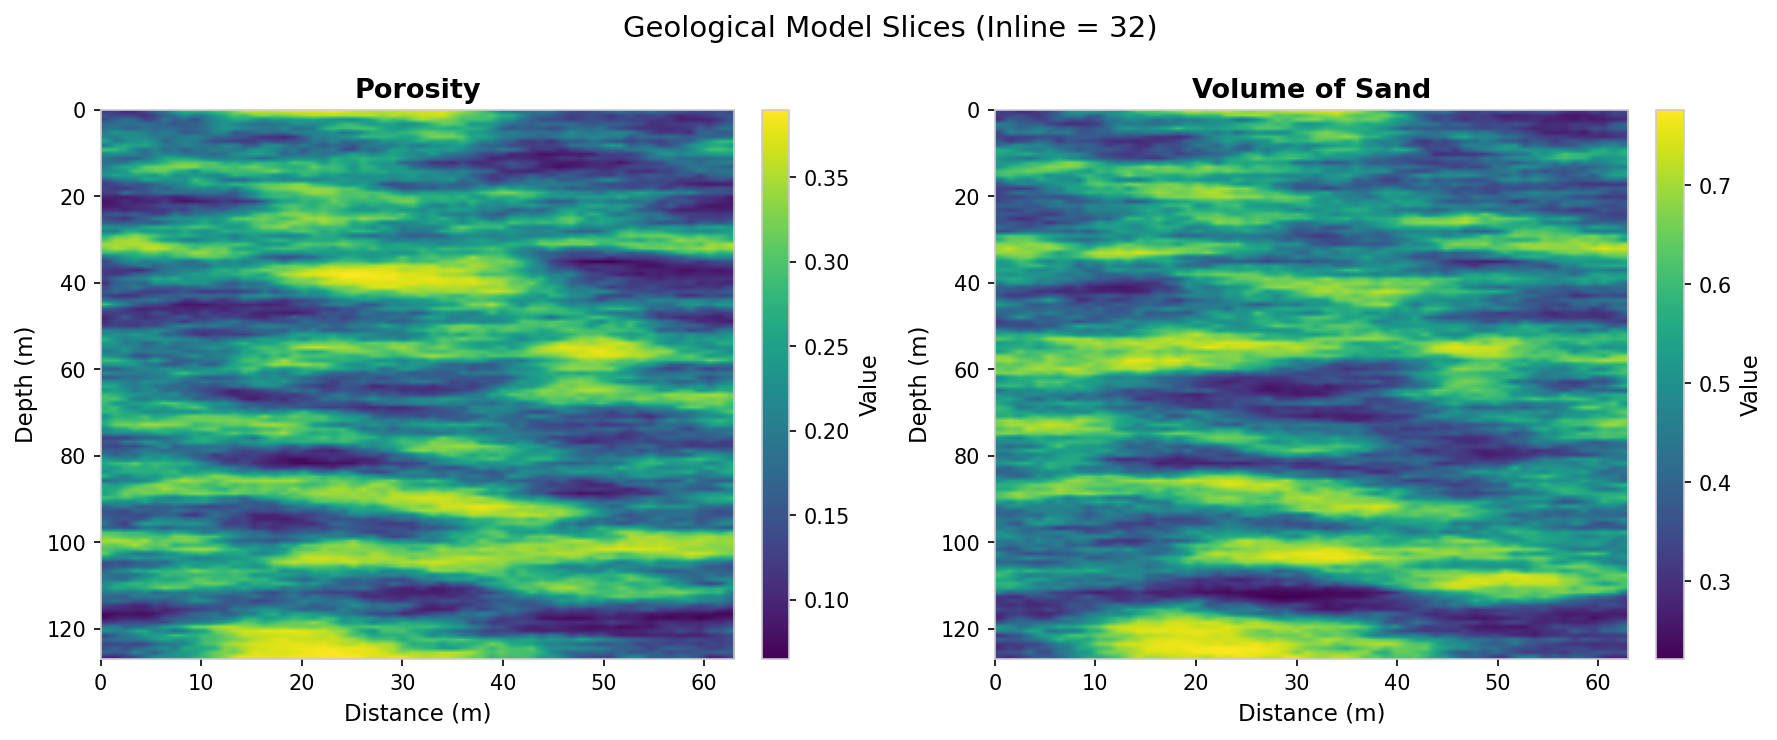

In [7]:
# Choose slice index to visualize
slice_idx = 32

# Plot porosity and sand volume side by side
fig, axes = plot_comparison(
    [phi[slice_idx].T, vsand[slice_idx].T],
    titles=['Porosity', 'Volume of Sand'],
    cmap='viridis',
    share_clim=False,
    label='Value',
    figsize=(12, 5),
)
fig.suptitle(f"Geological Model Slices (Inline = {slice_idx})", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '02_cosim_properties.png'))
plt.show()

## Unconditional SGS Simulation

**Sequential Gaussian Simulation (SGS)** visits grid nodes in random order
and performs kriging estimation + conditional sampling at each node.

Two kriging variants are compared:

| Variant | Description |
|---------|-------------|
| **Simple Kriging (SK)** | Assumes a known, constant global mean |
| **Ordinary Kriging (OK)** | Estimates the mean locally — more flexible |


--- Unconditional SGS (3D) ---
SK SGS shape: torch.Size([2, 64, 64, 64])
SK SGS: mean=0.0105, std=0.9899
OK SGS shape: torch.Size([2, 64, 64, 64])
OK SGS: mean=0.0425, std=1.0625


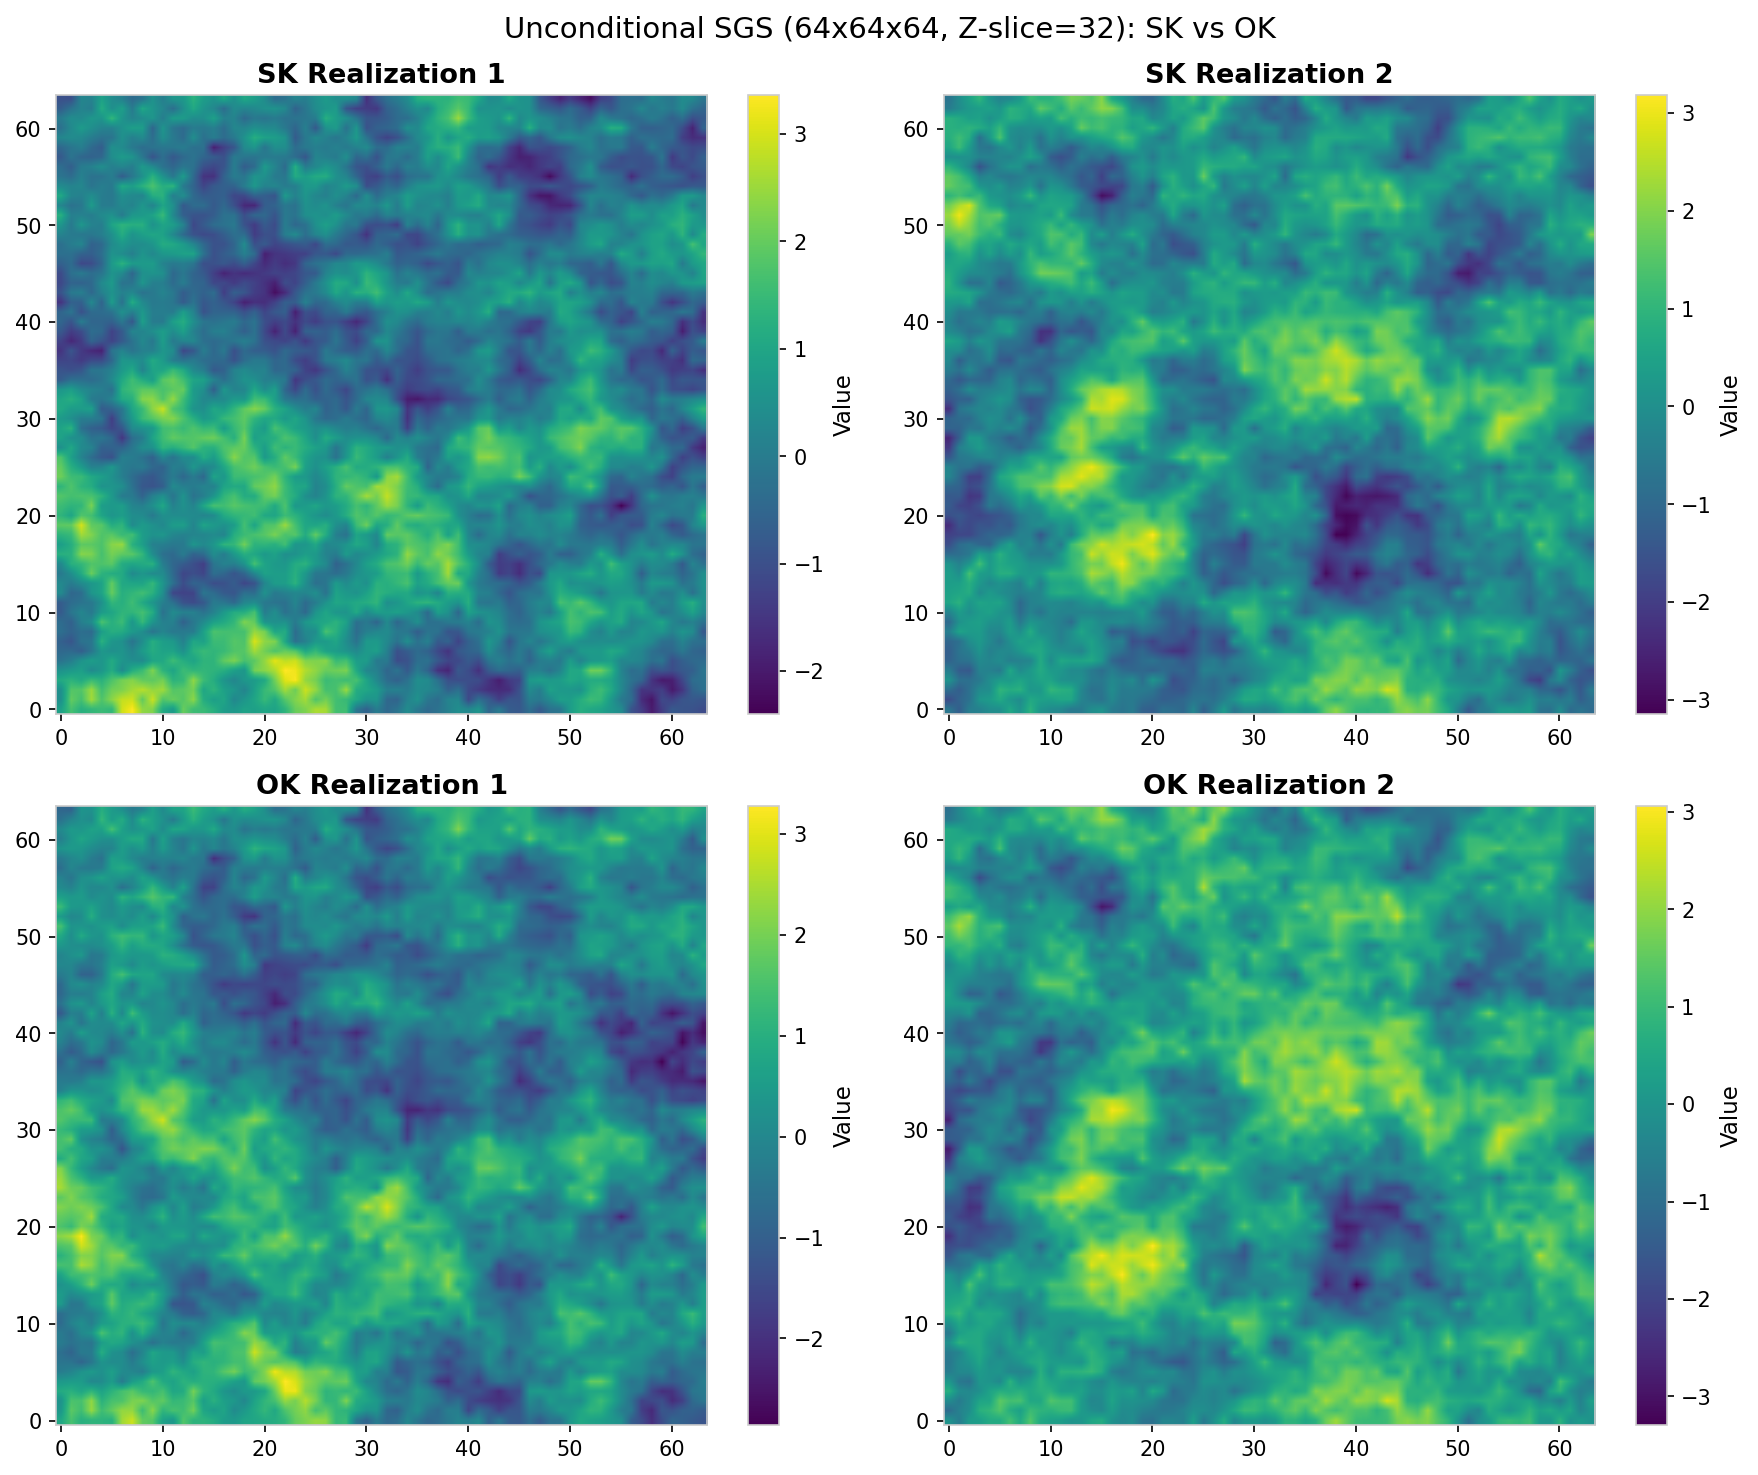

In [8]:
print("\n--- Unconditional SGS (3D) ---")

config_sgs = SimulationConfig(
    shape=(64, 64, 64),
    lh=10.0,
    lv=5.0,
    n_realizations=2,
    seed=42,
    device=str(device),
)

# Simple Kriging
sim_sk = Simulator.create('sgs', kriging_type='sk')
fields_sk = sim_sk.simulate(config_sgs)

print(f"SK SGS shape: {fields_sk.shape}")
print(f"SK SGS: mean={fields_sk.mean():.4f}, std={fields_sk.std():.4f}")

# Ordinary Kriging
sim_ok = Simulator.create('sgs', kriging_type='ok')
fields_ok = sim_ok.simulate(config_sgs)

print(f"OK SGS shape: {fields_ok.shape}")
print(f"OK SGS: mean={fields_ok.mean():.4f}, std={fields_ok.std():.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

slice_idx = 32  # Middle Z-slice

for i in range(2):
    data_sk = fields_sk[i, :, :, slice_idx].detach().cpu().numpy()
    im = axes[0, i].imshow(data_sk.T, origin='lower', cmap='viridis', aspect='auto',
                           interpolation='bilinear')
    axes[0, i].set_title(f'SK Realization {i+1}')
    plt.colorbar(im, ax=axes[0, i], label='Value')

    data_ok = fields_ok[i, :, :, slice_idx].detach().cpu().numpy()
    im = axes[1, i].imshow(data_ok.T, origin='lower', cmap='viridis', aspect='auto',
                           interpolation='bilinear')
    axes[1, i].set_title(f'OK Realization {i+1}')
    plt.colorbar(im, ax=axes[1, i], label='Value')

fig.suptitle('Unconditional SGS (64x64x64, Z-slice=32): SK vs OK', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '02_sgs_unconditional.png'))
plt.show()

## Conditional SGS — Honouring Well Data

In **conditional simulation**, the generated field must match observed
values exactly at specified data locations (e.g., wells).

Five synthetic "wells" are defined at known grid positions.  After
simulation, we verify that the simulated values at those locations match the
conditioning data to within floating-point tolerance.  Red circles on the
plot mark the well positions.


--- Conditional SGS (3D) ---
Conditional SGS shape: torch.Size([2, 64, 64, 64])
Well data verification:
  Well (16,16,32): expected=0.80, simulated=0.8000 [OK]
  Well (16,48,32): expected=-0.50, simulated=-0.5000 [OK]
  Well (48,16,32): expected=1.20, simulated=1.2000 [OK]
  Well (48,48,32): expected=-1.00, simulated=-1.0000 [OK]
  Well (32,32,32): expected=0.30, simulated=0.3000 [OK]


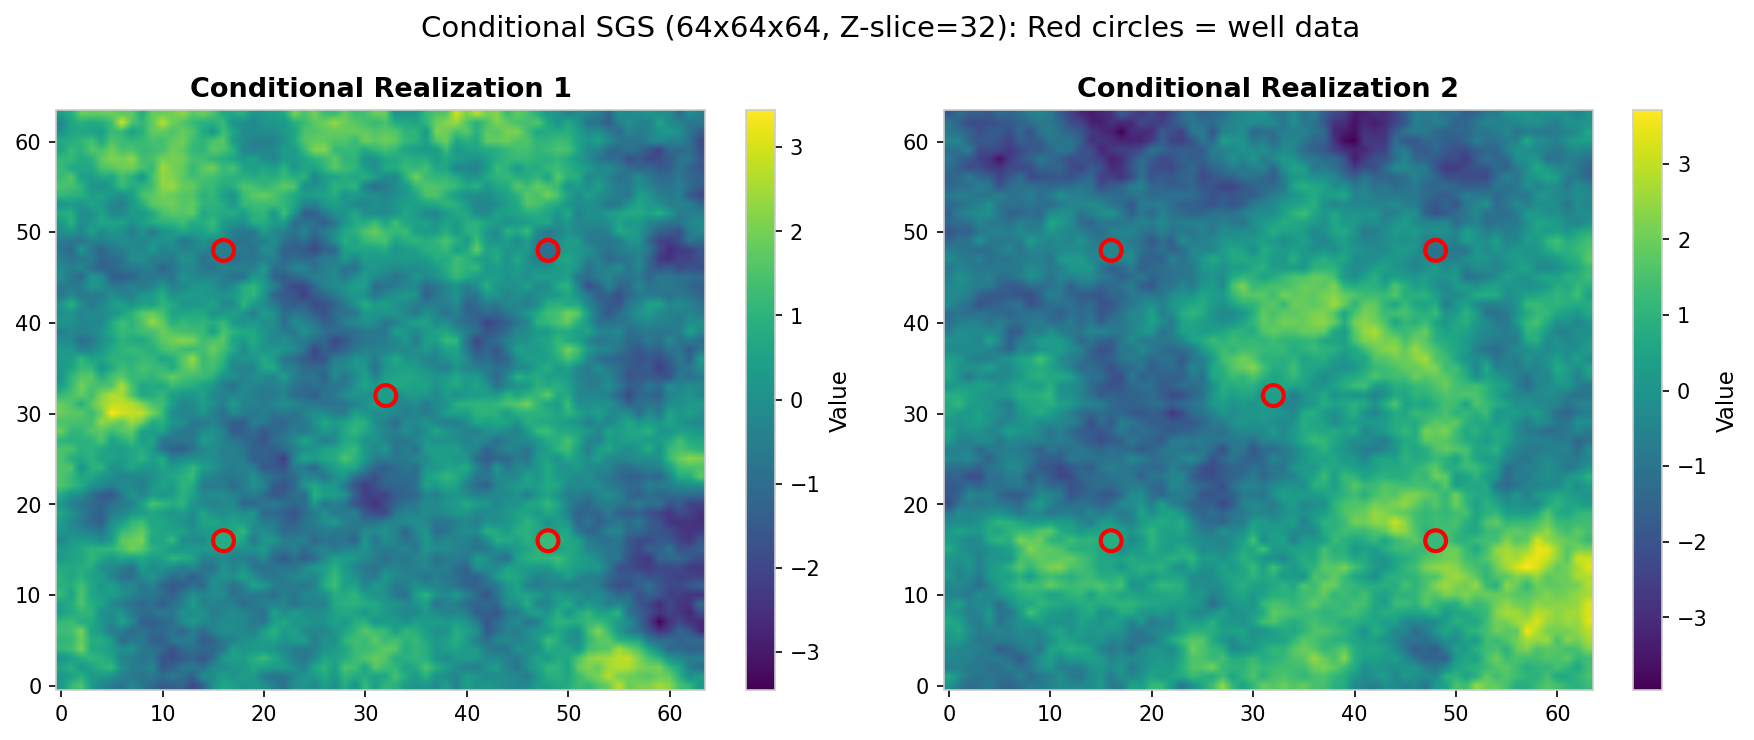

In [9]:
print("\n--- Conditional SGS (3D) ---")

# Define well data (conditioning points with 3D coordinates)
# Wells penetrate at a specific Z-layer (z=32, the middle slice)
well_locations = torch.tensor([
    [16., 16., 32.],
    [16., 48., 32.],
    [48., 16., 32.],
    [48., 48., 32.],
    [32., 32., 32.],
])
well_values = torch.tensor([0.8, -0.5, 1.2, -1.0, 0.3])

config_cond = SimulationConfig(
    shape=(64, 64, 64),
    lh=12.0,
    lv=5.0,
    n_realizations=2,
    seed=2025,
    device=str(device),
)

sim_cond = Simulator.create('sgs', kriging_type='ok')
sim_cond.set_conditioning(well_values, well_locations)
fields_cond = sim_cond.simulate(config_cond)

print(f"Conditional SGS shape: {fields_cond.shape}")

# Verify conditioning data is honored
print("Well data verification:")
for i in range(len(well_values)):
    ix = int(well_locations[i, 0])
    iy = int(well_locations[i, 1])
    iz = int(well_locations[i, 2])
    sim_val = fields_cond[0, ix, iy, iz].item()
    true_val = well_values[i].item()
    match = "OK" if abs(sim_val - true_val) < 1e-5 else "MISMATCH"
    print(f"  Well ({ix},{iy},{iz}): expected={true_val:.2f}, simulated={sim_val:.4f} [{match}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

slice_idx = 32  # Z-slice where wells are located

for i in range(2):
    data = fields_cond[i, :, :, slice_idx].detach().cpu().numpy()
    im = axes[i].imshow(data.T, origin='lower', cmap='viridis', aspect='auto',
                        interpolation='bilinear')
    # Plot well locations on this slice
    axes[i].scatter(
        well_locations[:, 0].numpy(),
        well_locations[:, 1].numpy(),
        c=well_values.numpy(), cmap='viridis',
        edgecolors='red', linewidths=2, s=100, zorder=5,
        vmin=data.min(), vmax=data.max(),
    )
    axes[i].set_title(f'Conditional Realization {i+1}')
    plt.colorbar(im, ax=axes[i], label='Value')

fig.suptitle('Conditional SGS (64x64x64, Z-slice=32): Red circles = well data', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '02_sgs_conditional.png'))
plt.show()

## Variogram Models

A variogram $\gamma(h)$ describes how dissimilarity grows with separation
distance $h$.  `VariogramModel` supports nested structures
(nugget + one or more structures), each defined by:

- **Model type**: spherical, exponential, or gaussian
- **Contribution** (partial sill)
- **Range**: distance at which the sill is effectively reached

The plot overlays three basic model types with the same range and sill,
making their shape differences easy to compare.


--- Variogram Model ---
Sill (nugget + contributions): 0.9999999999999999
C(0,0,0) = 0.9000
C(10,0,0) = 0.5173
C(50,0,0) = 0.0460


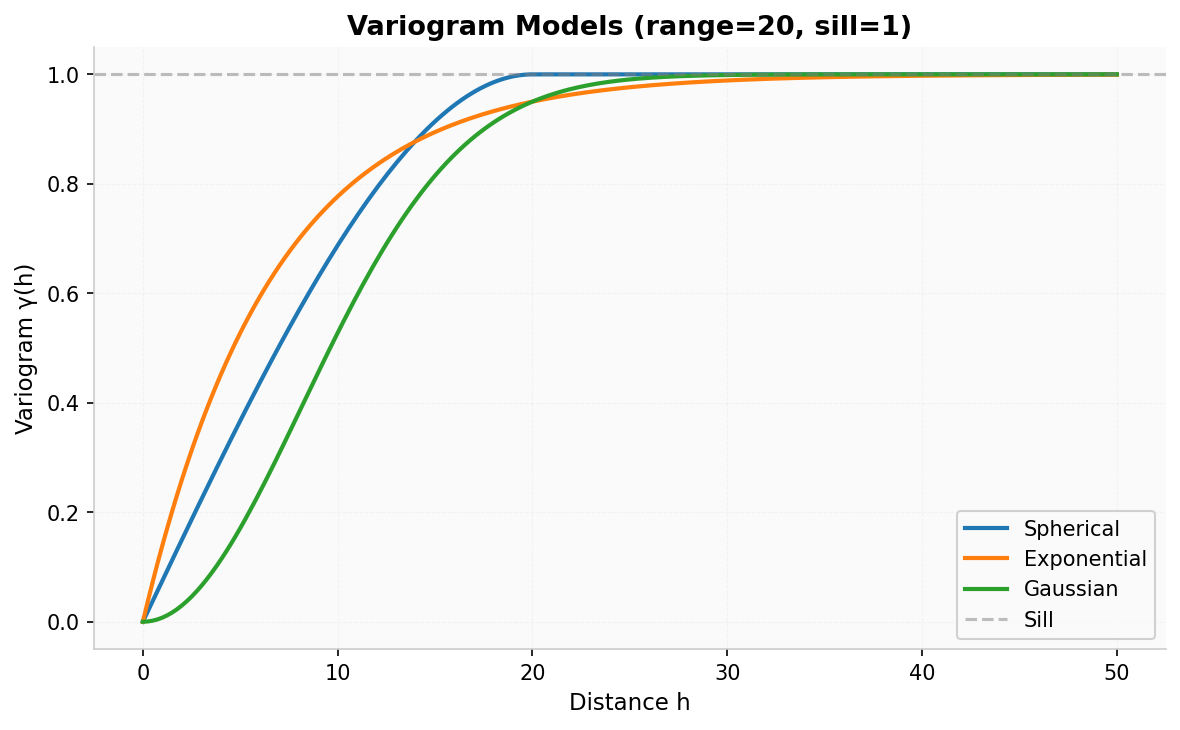

In [10]:
print("\n--- Variogram Model ---")

# Create variogram model manually
vario = VariogramModel(
    nugget=0.1,
    structures=[
        VariogramStructure('spherical', contribution=0.6, range_h=30.0, range_v=10.0),
        VariogramStructure('exponential', contribution=0.3, range_h=80.0, range_v=20.0),
    ]
)

print(f"Sill (nugget + contributions): {vario.sill}")
print(f"C(0,0,0) = {vario.covariance_3d(0, 0, 0):.4f}")
print(f"C(10,0,0) = {vario.covariance_3d(10, 0, 0):.4f}")
print(f"C(50,0,0) = {vario.covariance_3d(50, 0, 0):.4f}")

# Plot variogram curve for different models
distances = np.linspace(0, 50, 200)
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for idx, model_name in enumerate(['spherical', 'exponential', 'gaussian']):
    vm = VariogramModel(
        nugget=0.0,
        structures=[VariogramStructure(model_name, 1.0, 20.0)]
    )
    gamma = [vm.sill - vm.covariance_3d(d, 0, 0) for d in distances]
    ax.plot(distances, gamma, label=model_name.capitalize(), linewidth=2, color=colors[idx])

ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Sill')
ax.set_xlabel('Distance h')
ax.set_ylabel('Variogram γ(h)')
ax.set_title('Variogram Models (range=20, sill=1)')
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '02_variogram_models.png'))
plt.show()